## Comparison of PLiCat with Random Forest, Logistic Regression, and Support Vector Machine.

To compare with traditional machine learning models, we used the ProtPy method to extract common biological features from protein sequences. We conducted a comprehensive comparison with three conventional machine learning models: Random Forest, Logistic Regression, and Support Vector Machine. For fairness, each baseline model was trained and tested using the same training, validation, and test sets. Our PLiCat framework outperformed all reference models in terms of Accuracy, Precision, Recall, Macro F1-score, AUC-ROC, and AUC-PR metrics.

In [6]:
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import ClassifierChain
from sklearn.metrics import roc_auc_score
from protpy import amino_acids as protpyAA

In [8]:
import protpy
print(protpy.__version__)

1.2.1


In [2]:
def make_features(sequence):
    features = [protpy.amino_acid_composition(sequence)]
    for key in ["hydrophobicity", "polarity", "charge", "solvent_accessibility", "polarizability"]:
        features.extend([
            protpy.ctd_composition(sequence, property=key),
            protpy.ctd_transition(sequence, property=key),
            protpy.ctd_distribution(sequence, property=key)
        ])  
    features = pd.concat(features, axis=1)
    features = np.array(features)
    return features

### 1 feature extraction of the training set

In [1]:
import pandas as pd
import numpy as np
import protpy  # Make sure the protpy library is installed
from tqdm import tqdm

# -----------------------------
# make_features function (from your definition)
# -----------------------------
def make_features(sequence):
    features = [protpy.amino_acid_composition(sequence)]
    for key in ["hydrophobicity", "polarity", "charge", "solvent_accessibility", "polarizability"]:
        features.extend([
            protpy.ctd_composition(sequence, property=key),
            protpy.ctd_transition(sequence, property=key),
            protpy.ctd_distribution(sequence, property=key)
        ])
    features = pd.concat(features, axis=1)
    features = np.array(features)
    return features

# -----------------------------
# Read dataset
# -----------------------------
df = pd.read_csv("./data/train_dataset.csv")

# Check if the Sequence column exists
if "Sequence" not in df.columns:
    raise ValueError("❌ The dataset does not contain a column named 'Sequence'!")

# -----------------------------
# Extract features for each sequence
# -----------------------------
print("🔍 Extracting protein sequence features...")
sequence_features = []
for seq in tqdm(df["Sequence"], desc="Extracting features"):
    try:
        feats = make_features(seq)
        # Flatten to 1D vector for saving
        sequence_features.append(feats.flatten())
    except Exception as e:
        print(f"⚠️ Error processing sequence: {seq[:10]}... Reason: {e}")
        sequence_features.append(np.nan)

# -----------------------------
# Add features as a new column in the DataFrame
# -----------------------------
df["Sequence_features"] = sequence_features

# -----------------------------
# Fix inconsistent feature lengths
# -----------------------------
def fix_feature_length(x, target_len=125):
    """Ensure each feature vector has the same length; pad with zeros if too short, truncate if too long"""
    if isinstance(x, (list, np.ndarray)):
        x = np.array(x, dtype=float)
        if len(x) < target_len:
            # Pad with zeros
            x = np.pad(x, (0, target_len - len(x)), 'constant')
        elif len(x) > target_len:
            # Truncate if too long
            x = x[:target_len]
        return x
    else:
        # Return all zeros for features that failed to parse
        return np.zeros(target_len)

df["Sequence_features"] = df["Sequence_features"].apply(fix_feature_length)

# -----------------------------
# Save results
# -----------------------------
df.to_csv("./data/train_dataset_with_features.csv", index=False)

print("✅ Feature extraction completed! Saved as train_dataset_with_features.csv")


🔍 Extracting protein sequence features...


Extracting features:   5%|██▉                                                     | 646/12305 [00:02<00:44, 259.96it/s]

⚠️ Error processing sequence: VLDLGALGQD... Reason: Invalid amino acid found in protein sequence: t.


Extracting features:   7%|███▊                                                    | 831/12305 [00:03<00:44, 255.37it/s]

⚠️ Error processing sequence: MSLLTEVETP... Reason: Invalid amino acid found in protein sequence: X.
⚠️ Error processing sequence: TTNTDSFTFS... Reason: Invalid amino acid found in protein sequence: X.


...

⚠️ Error processing sequence: TTNTDSFTFS... Reason: Invalid amino acid found in protein sequence: X.


Extracting features:  88%|███████████████████████████████████████████████▍      | 10811/12305 [00:41<00:05, 276.34it/s]

⚠️ Error processing sequence: AEETSFVFSK... Reason: Invalid amino acid found in protein sequence: X.


Extracting features: 100%|██████████████████████████████████████████████████████| 12305/12305 [00:47<00:00, 261.69it/s]


✅ Feature extraction completed! Saved as train_dataset_with_features.csv


In [23]:
df.head()

,ID,Sequence,Label,Sequence_features
0,LP-1-9560,MHRIWLMYDPRRVMVALVGFLAVLALVIHFVLLSSQRYSWIENGTL...,0 0 1 0 0 1 0 0 0,"[15.493, 0.0, 2.817, 2.817, 2.817, 7.042, 2.81..."
1,LP-1-13709,MSGYTPEEKLRLQQLRELRRRWLKDQELSPREPVLPPQRVSPVERF...,0 1 0 1 1 0 0 0 0,"[1.562, 0.0, 3.125, 7.812, 4.688, 3.125, 4.688..."
2,LP-1-5465,MLGLTLMFKRFFGAVRTSWRDPSTRGAVLSLAIIVTAATIFYTLAE...,0 1 0 0 0 0 0 0 0,"[9.302, 0.0, 2.326, 3.101, 6.202, 7.752, 4.651..."
3,LP-1-2306,ERPVWYPGKAPAPHLDGSLPGDFGFDPLSLSADPEMRKWMVQAELQ...,0 0 1 0 0 0 0 0 0,"[10.732, 0.488, 5.854, 3.902, 4.878, 11.22, 1...."
4,LP-1-5766,CHCVILNDGNFIPVLGFGTALPLECPASKAKELTKIAIDAGFHHFD...,0 0 0 0 1 0 0 0 0,"[5.956, 2.821, 5.956, 6.583, 4.389, 5.956, 2.8..."


In [14]:
df['Sequence_features'][100].shape

(125,)

In [13]:
len(df)

12305

## 2 feature extraction of the test set

In [2]:
import pandas as pd
import numpy as np
import protpy  # Make sure the protpy library is installed
from tqdm import tqdm

# -----------------------------
# make_features function (from your definition)
# -----------------------------
def make_features(sequence):
    features = [protpy.amino_acid_composition(sequence)]
    for key in ["hydrophobicity", "polarity", "charge", "solvent_accessibility", "polarizability"]:
        features.extend([
            protpy.ctd_composition(sequence, property=key),
            protpy.ctd_transition(sequence, property=key),
            protpy.ctd_distribution(sequence, property=key)
        ])
    features = pd.concat(features, axis=1)
    features = np.array(features)
    return features

# -----------------------------
# Read dataset
# -----------------------------
df = pd.read_csv("./data/test_dataset.csv")

# Check if the Sequence column exists
if "Sequence" not in df.columns:
    raise ValueError("❌ The dataset does not contain a column named 'Sequence'!")

# -----------------------------
# Extract features for each sequence
# -----------------------------
print("🔍 Extracting protein sequence features...")
sequence_features = []
for seq in tqdm(df["Sequence"], desc="Extracting features"):
    try:
        feats = make_features(seq)
        # Flatten to 1D vector for saving
        sequence_features.append(feats.flatten())
    except Exception as e:
        print(f"⚠️ Error processing sequence: {seq[:10]}... Reason: {e}")
        sequence_features.append(np.nan)

# -----------------------------
# Add features as a new column in the DataFrame
# -----------------------------
df["Sequence_features"] = sequence_features

# -----------------------------
# Fix inconsistent feature lengths
# -----------------------------
def fix_feature_length(x, target_len=125):
    """Ensure each feature vector has the same length; pad with zeros if too short, truncate if too long"""
    if isinstance(x, (list, np.ndarray)):
        x = np.array(x, dtype=float)
        if len(x) < target_len:
            # Pad with zeros
            x = np.pad(x, (0, target_len - len(x)), 'constant')
        elif len(x) > target_len:
            # Truncate if too long
            x = x[:target_len]
        return x
    else:
        # Return all zeros for features that failed to parse
        return np.zeros(target_len)

df["Sequence_features"] = df["Sequence_features"].apply(fix_feature_length)

# -----------------------------
# Save results
# -----------------------------
df.to_csv("./data/test_dataset_with_features.csv", index=False)

print("✅ Feature extraction completed! Saved as test_dataset_with_features.csv")


🔍 Extracting protein sequence features...


Extracting features: 100%|████████████████████████████████████████████████████████| 1368/1368 [00:05<00:00, 260.76it/s]


✅ Feature extraction completed! Saved as test_dataset_with_features.csv


In [1]:
import numpy as np
import pandas as pd
import ast  # Safe alternative to eval

# Safe parsing function
def parse_feature_string(x):
    if isinstance(x, str):
        # Fix cases with missing commas
        s = x.replace('  ', ' ').replace('[ ', '[').strip()
        if ',' not in s:  # If there are no commas in the string, split by spaces
            try:
                arr = np.fromstring(s.strip('[]'), sep=' ')
                return arr
            except Exception:
                return np.nan
        else:
            try:
                arr = np.array(ast.literal_eval(s))
                return arr
            except Exception:
                return np.nan
    elif isinstance(x, (list, np.ndarray)):
        return np.array(x)
    else:
        return np.nan


In [2]:
def get_proba_matrix(multi_target_model, X):
    """
    Convert the output of ClassifierChain.predict_proba to a probability matrix of shape (n_samples, n_labels).
    Compatible with single-class label cases.
    """
    pred_list = multi_target_model.predict_proba(X)
    pred_prob_fixed = []
    for p in pred_list:
        p = np.array(p)
        if p.ndim == 1:
            # Extreme labels (all 0s or all 1s)
            pred_prob_fixed.append(p)
        elif p.shape[1] == 1:
            # 2D array with only one column
            pred_prob_fixed.append(p[:, 0])
        else:
            # Standard binary classification
            pred_prob_fixed.append(p[:, 1])
    return np.array(pred_prob_fixed)


### 3 training the random forest model

训练集特征矩阵: (11074, 125), 验证集特征矩阵: (1231, 125)
训练集标签矩阵: (11074, 9), 验证集标签矩阵: (1231, 9)
模型开始训练....
模型开始推理预测....

📘 训练集评估指标：
Accuracy    : 0.9967
Precision   : 0.9986
Recall      : 0.9975
F1-score    : 0.9981
AUC-ROC     : 0.9999
AUC-PR      : 0.9979

📗 验证集评估指标：
Accuracy    : 0.6312
Precision   : 0.8838
Recall      : 0.5208
F1-score    : 0.6127
AUC-ROC     : 0.9245
AUC-PR      : 0.7251

📗 测试评估指标：
Accuracy    : 0.6096
Precision   : 0.8426
Recall      : 0.4926
F1-score    : 0.5925
AUC-ROC     : 0.9205
AUC-PR      : 0.6911


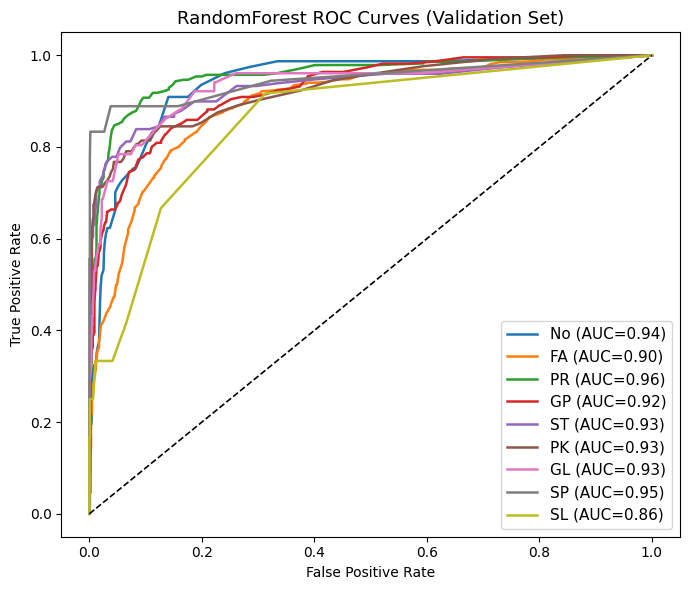

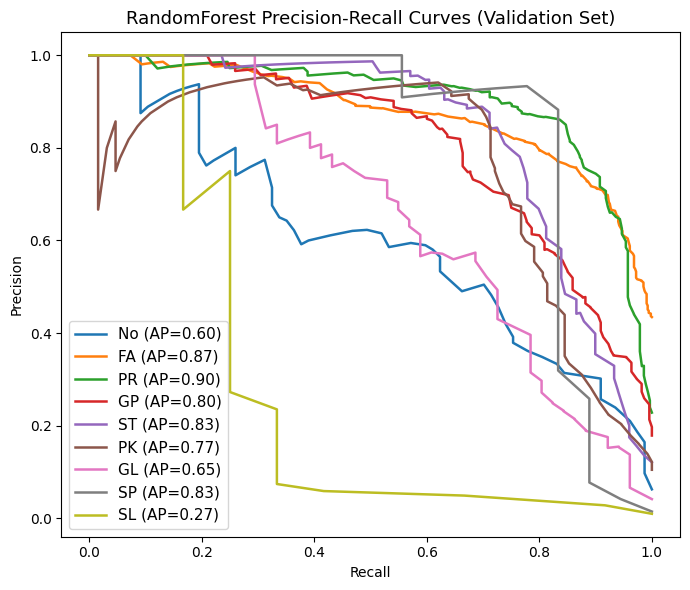

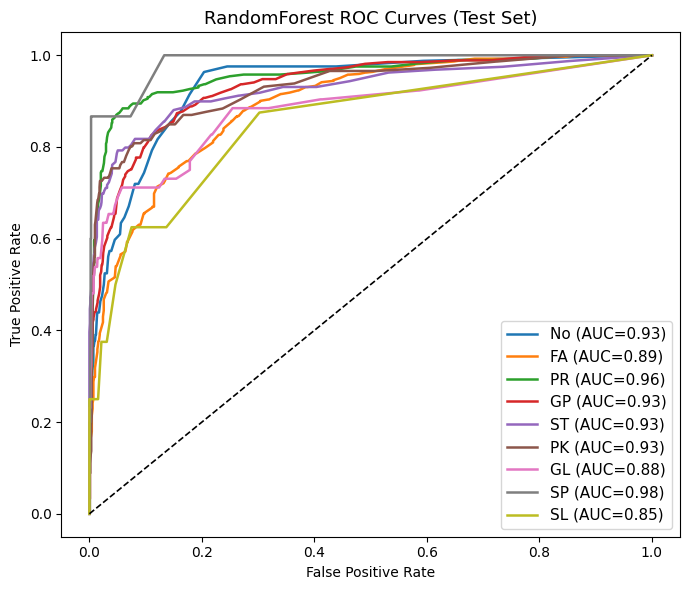

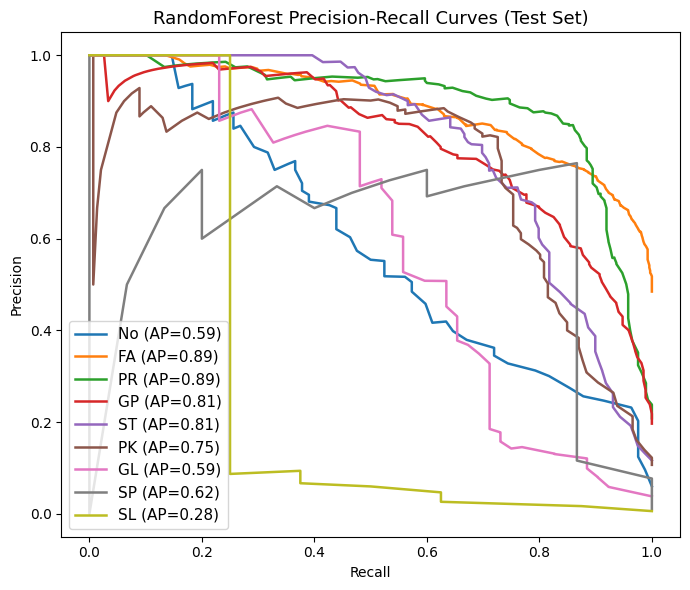

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import ClassifierChain
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)

# -----------------------------
# 1. Load dataset
# -----------------------------
df = pd.read_csv("./data/train_dataset_with_features.csv")

# -----------------------------
# 2. Data preprocessing
# -----------------------------
# Parse the Sequence_features column: convert from string to numeric list
df["Sequence_features"] = df["Sequence_features"].apply(parse_feature_string)
df["Sequence_features"] = df["Sequence_features"].apply(
    lambda x: np.array(eval(x)) if isinstance(x, str) else np.array(x)
)

# -----------------------------
# 3. Construct feature and label matrices
# -----------------------------
X = np.stack(df["Sequence_features"].values)  # shape: (n_samples, n_features)

# Assume the Label column is already in string form "0 0 1 0 0 1 0 0 0"
df["Label"] = df["Label"].apply(lambda x: np.array([int(i) for i in str(x).split()]))

# Stack into a 2D array
Y = np.stack(df["Label"].values)  # shape: (n_samples, n_labels)

# -----------------------------
# 4. Split training and validation sets (9:1 ratio)
# -----------------------------
trainX, valX, trainY, valY = train_test_split(
    X, Y, test_size=0.1, random_state=42
)

print(f"Training feature matrix: {trainX.shape}, Validation feature matrix: {valX.shape}")
print(f"Training label matrix: {trainY.shape}, Validation label matrix: {valY.shape}")

# -----------------------------
# 5. Define model: Random Forest + ClassifierChain
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=400,
    random_state=0
)

multi_target_rf = ClassifierChain(rf)
print('Model training started....')
multi_target_rf.fit(trainX, trainY)

# -----------------------------
# 6. Model prediction
# -----------------------------
print('Model inference started....')

# -----------------------------
# 7. Compute evaluation metrics
# -----------------------------
def evaluate_metrics(y_true, y_pred, y_prob):
    metrics = {}
    metrics["Accuracy"]  = accuracy_score(y_true, y_pred)
    metrics["Precision"] = precision_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["Recall"]    = recall_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["F1-score"]  = f1_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["AUC-ROC"]   = roc_auc_score(y_true, y_prob, average="macro")
    metrics["AUC-PR"]    = average_precision_score(y_true, y_prob, average="macro")
    return metrics

# Training set predicted probabilities
trainY_prob = get_proba_matrix(multi_target_rf, trainX)
trainY_pred = (trainY_prob >= 0.5).astype(int)

train_metrics = evaluate_metrics(trainY, trainY_pred, trainY_prob)

# Validation set metrics
valY_prob = get_proba_matrix(multi_target_rf, valX)
valY_pred = (valY_prob >= 0.5).astype(int)
val_metrics = evaluate_metrics(valY, valY_pred, valY_prob)

# Load test set
df = pd.read_csv("./data/test_dataset_with_features.csv")

# -----------------------------
# 2. Data preprocessing
# -----------------------------
# Parse the Sequence_features column: convert from string to numeric list
df["Sequence_features"] = df["Sequence_features"].apply(parse_feature_string)
df["Sequence_features"] = df["Sequence_features"].apply(
    lambda x: np.array(eval(x)) if isinstance(x, str) else np.array(x)
)

# -----------------------------
# 3. Construct feature and label matrices
# -----------------------------
testX = np.stack(df["Sequence_features"].values)  # shape: (n_samples, n_features)

# Assume Label column is in string form "0 0 1 0 0 1 0 0 0"
df["Label"] = df["Label"].apply(lambda x: np.array([int(i) for i in str(x).split()]))

# Stack into 2D array
testY = np.stack(df["Label"].values)  # shape: (n_samples, n_labels)

# Test predicted probabilities
testY_prob = get_proba_matrix(multi_target_rf, testX)
testY_pred = (testY_prob >= 0.5).astype(int)
test_metrics = evaluate_metrics(testY, testY_pred, testY_prob)

# -----------------------------
# 8. Output results
# -----------------------------
print("\n📘 Training set evaluation metrics:")
for k, v in train_metrics.items():
    print(f"{k:12s}: {v:.4f}")

print("\n📗 Validation set evaluation metrics:")
for k, v in val_metrics.items():
    print(f"{k:12s}: {v:.4f}")

print("\n📗 Test set evaluation metrics:")
for k, v in test_metrics.items():
    print(f"{k:12s}: {v:.4f}")

# If your 9 label names are known
label_names = ["No","FA","PR","GP","ST","PK","GL","SP","SL"]

# -----------------------------
# 6. Plot ROC curves for validation set
# -----------------------------
plt.figure(figsize=(7,6))
for i in range(Y.shape[1]):
    fpr, tpr, _ = roc_curve(valY[:, i], valY_prob[:, i])
    auc = roc_auc_score(valY[:, i], valY_prob[:, i])
    plt.plot(fpr, tpr, lw=1.8, label=f"{label_names[i]} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=1.2)
plt.xlabel("False Positive Rate", fontsize=10)
plt.ylabel("True Positive Rate", fontsize=10)
plt.title("RandomForest ROC Curves (Validation Set)", fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("RandomForest_val_roc_curves.png", dpi=300)
plt.show()

# -----------------------------
# 7. Plot Precision-Recall curves for validation set
# -----------------------------
plt.figure(figsize=(7,6))
for i in range(Y.shape[1]):
    precision, recall, _ = precision_recall_curve(valY[:, i], valY_prob[:, i])
    ap = average_precision_score(valY[:, i], valY_prob[:, i])
    plt.plot(recall, precision, lw=1.8, label=f"{label_names[i]} (AP={ap:.2f})")

plt.xlabel("Recall", fontsize=10)
plt.ylabel("Precision", fontsize=10)
plt.title("RandomForest Precision-Recall Curves (Validation Set)", fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("RandomForest_val_pr_curves.png", dpi=300)
plt.show()

# -----------------------------
# 8. Plot ROC curves for test set
# -----------------------------
plt.figure(figsize=(7,6))
for i in range(Y.shape[1]):
    fpr, tpr, _ = roc_curve(testY[:, i], testY_prob[:, i])
    auc = roc_auc_score(testY[:, i], testY_prob[:, i])
    plt.plot(fpr, tpr, lw=1.8, label=f"{label_names[i]} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=1.2)
plt.xlabel("False Positive Rate", fontsize=10)
plt.ylabel("True Positive Rate", fontsize=10)
plt.title("RandomForest ROC Curves (Test Set)", fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("RandomForest_test_roc_curves.png", dpi=300)
plt.show()

# -----------------------------
# 9. Plot Precision-Recall curves for test set
# -----------------------------
plt.figure(figsize=(7,6))
for i in range(Y.shape[1]):
    precision, recall, _ = precision_recall_curve(testY[:, i], testY_prob[:, i])
    ap = average_precision_score(testY[:, i], testY_prob[:, i])
    plt.plot(recall, precision, lw=1.8, label=f"{label_names[i]} (AP={ap:.2f})")

plt.xlabel("Recall", fontsize=10)
plt.ylabel("Precision", fontsize=10)
plt.title("RandomForest Precision-Recall Curves (Test Set)", fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("RandomForest_test_pr_curves.png", dpi=300)
plt.show()


### 4 training the Logistic Regression model

训练集特征矩阵: (11074, 125), 验证集特征矩阵: (1231, 125)
训练集标签矩阵: (11074, 9), 验证集标签矩阵: (1231, 9)
模型开始训练....


C:\Users\upsun\Desktop\Ai\pytorch\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


模型开始推理预测....

📘 LogisticRegression 训练集评估指标：
Accuracy    : 0.3934
Precision   : 0.4745
Recall      : 0.3322
F1-score    : 0.3766
AUC-ROC     : 0.8112
AUC-PR      : 0.3988

📗 LogisticRegression 验证集评估指标：
Accuracy    : 0.3932
Precision   : 0.4648
Recall      : 0.3365
F1-score    : 0.3774
AUC-ROC     : 0.8009
AUC-PR      : 0.4143

📗 LogisticRegression 测试评估指标：
Accuracy    : 0.3816
Precision   : 0.4578
Recall      : 0.2900
F1-score    : 0.3392
AUC-ROC     : 0.8015
AUC-PR      : 0.3674


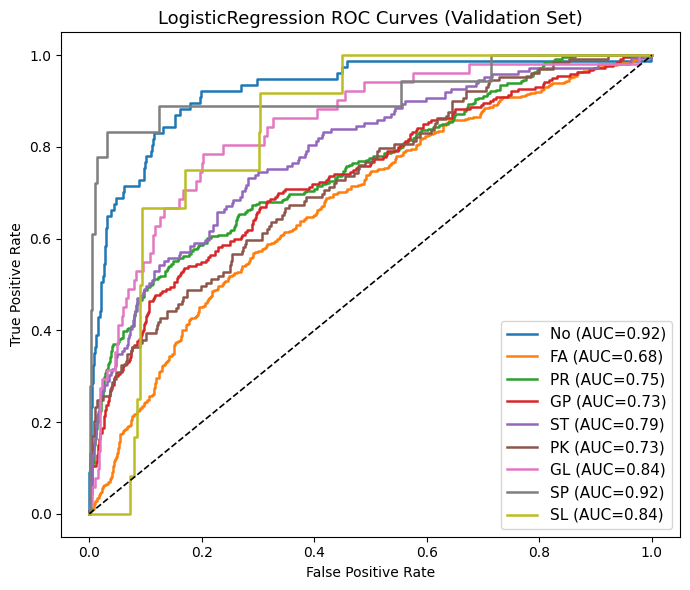

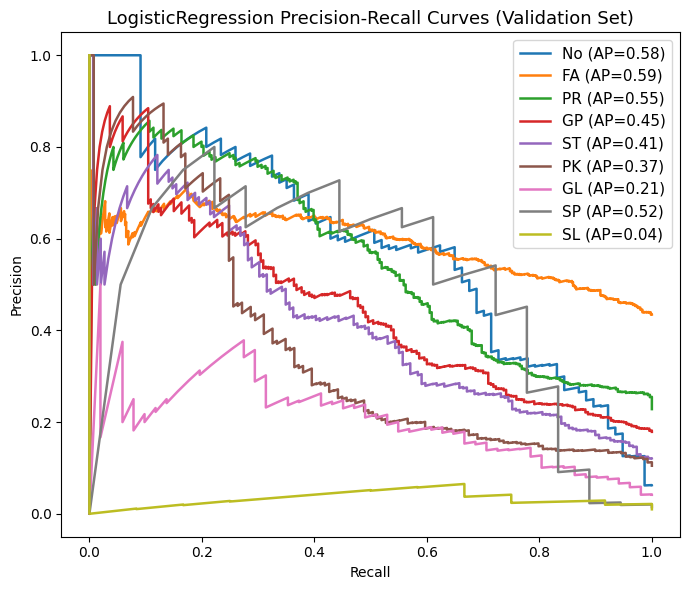

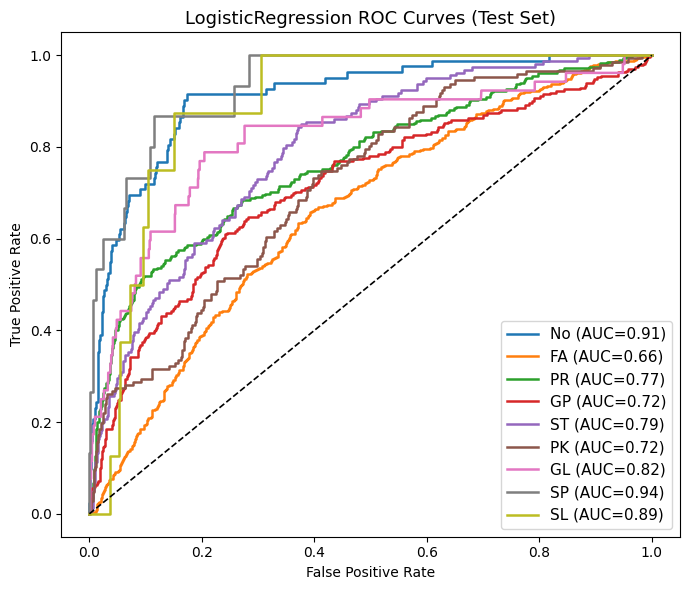

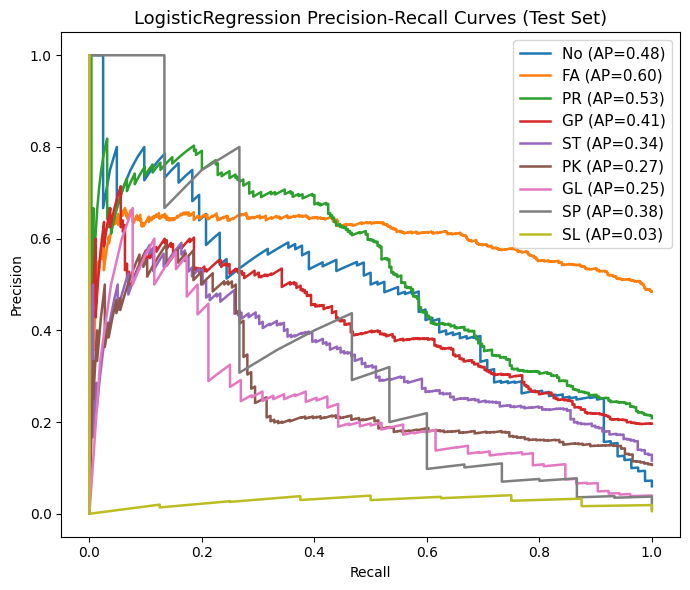

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import ClassifierChain
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)

# -----------------------------
# 1. Load dataset
# -----------------------------
df = pd.read_csv("./data/train_dataset_with_features.csv")

# -----------------------------
# 2. Data preprocessing
# -----------------------------
# Parse the Sequence_features column: convert from string to numeric list
df["Sequence_features"] = df["Sequence_features"].apply(parse_feature_string)
df["Sequence_features"] = df["Sequence_features"].apply(
    lambda x: np.array(eval(x)) if isinstance(x, str) else np.array(x)
)

# -----------------------------
# 3. Construct feature and label matrices
# -----------------------------
X = np.stack(df["Sequence_features"].values)  # shape: (n_samples, n_features)

# Assume the Label column is already in string form "0 0 1 0 0 1 0 0 0"
df["Label"] = df["Label"].apply(lambda x: np.array([int(i) for i in str(x).split()]))

# Stack into a 2D array
Y = np.stack(df["Label"].values)  # shape: (n_samples, n_labels)

# -----------------------------
# 4. Split training and validation sets (9:1 ratio)
# -----------------------------
trainX, valX, trainY, valY = train_test_split(
    X, Y, test_size=0.1, random_state=42
)

print(f"Training feature matrix: {trainX.shape}, Validation feature matrix: {valX.shape}")
print(f"Training label matrix: {trainY.shape}, Validation label matrix: {valY.shape}")

# -----------------------------
# 5. Define model: Logistic Regression + ClassifierChain
# -----------------------------
logreg = LogisticRegression(solver="liblinear", random_state=0)

multi_target_lr = ClassifierChain(logreg)
print('Model training started....')
multi_target_lr.fit(trainX, trainY)

# -----------------------------
# 6. Model prediction
# -----------------------------
print('Model inference started....')

# -----------------------------
# 7. Compute evaluation metrics
# -----------------------------
def evaluate_metrics(y_true, y_pred, y_prob):
    metrics = {}
    metrics["Accuracy"]  = accuracy_score(y_true, y_pred)
    metrics["Precision"] = precision_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["Recall"]    = recall_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["F1-score"]  = f1_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["AUC-ROC"]   = roc_auc_score(y_true, y_prob, average="macro")
    metrics["AUC-PR"]    = average_precision_score(y_true, y_prob, average="macro")
    return metrics

# Training set predicted probabilities
trainY_prob = get_proba_matrix(multi_target_lr, trainX)
trainY_pred = (trainY_prob >= 0.5).astype(int)

train_metrics = evaluate_metrics(trainY, trainY_pred, trainY_prob)

# Validation set metrics
valY_prob = get_proba_matrix(multi_target_lr, valX)
valY_pred = (valY_prob >= 0.5).astype(int)
val_metrics = evaluate_metrics(valY, valY_pred, valY_prob)

# Load test set
df = pd.read_csv("./data/test_dataset_with_features.csv")

# -----------------------------
# 2. Data preprocessing
# -----------------------------
# Parse the Sequence_features column: convert from string to numeric list
df["Sequence_features"] = df["Sequence_features"].apply(parse_feature_string)
df["Sequence_features"] = df["Sequence_features"].apply(
    lambda x: np.array(eval(x)) if isinstance(x, str) else np.array(x)
)

# -----------------------------
# 3. Construct feature and label matrices
# -----------------------------
testX = np.stack(df["Sequence_features"].values)  # shape: (n_samples, n_features)

# Assume Label column is in string form "0 0 1 0 0 1 0 0 0"
df["Label"] = df["Label"].apply(lambda x: np.array([int(i) for i in str(x).split()]))

# Stack into 2D array
testY = np.stack(df["Label"].values)  # shape: (n_samples, n_labels)

# Test predicted probabilities
testY_prob = get_proba_matrix(multi_target_lr, testX)
testY_pred = (testY_prob >= 0.5).astype(int)
test_metrics = evaluate_metrics(testY, testY_pred, testY_prob)

# -----------------------------
# 8. Output results
# -----------------------------
print("\n📘 LogisticRegression Training Set Metrics:")
for k, v in train_metrics.items():
    print(f"{k:12s}: {v:.4f}")

print("\n📗 LogisticRegression Validation Set Metrics:")
for k, v in val_metrics.items():
    print(f"{k:12s}: {v:.4f}")

print("\n📗 LogisticRegression Test Set Metrics:")
for k, v in test_metrics.items():
    print(f"{k:12s}: {v:.4f}")

# If your 9 label names are known
label_names = ["No","FA","PR","GP","ST","PK","GL","SP","SL"]

# -----------------------------
# 6. Plot ROC curves for validation set
# -----------------------------
plt.figure(figsize=(7,6))
for i in range(Y.shape[1]):
    fpr, tpr, _ = roc_curve(valY[:, i], valY_prob[:, i])
    auc = roc_auc_score(valY[:, i], valY_prob[:, i])
    plt.plot(fpr, tpr, lw=1.8, label=f"{label_names[i]} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=1.2)
plt.xlabel("False Positive Rate", fontsize=10)
plt.ylabel("True Positive Rate", fontsize=10)
plt.title("LogisticRegression ROC Curves (Validation Set)", fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("LogisticRegression_val_roc_curves.png", dpi=300)
plt.show()

# -----------------------------
# 7. Plot Precision-Recall curves for validation set
# -----------------------------
plt.figure(figsize=(7,6))
for i in range(Y.shape[1]):
    precision, recall, _ = precision_recall_curve(valY[:, i], valY_prob[:, i])
    ap = average_precision_score(valY[:, i], valY_prob[:, i])
    plt.plot(recall, precision, lw=1.8, label=f"{label_names[i]} (AP={ap:.2f})")

plt.xlabel("Recall", fontsize=10)
plt.ylabel("Precision", fontsize=10)
plt.title("LogisticRegression Precision-Recall Curves (Validation Set)", fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("LogisticRegression_val_pr_curves.png", dpi=300)
plt.show()

# -----------------------------
# 8. Plot ROC curves for test set
# -----------------------------
plt.figure(figsize=(7,6))
for i in range(Y.shape[1]):
    fpr, tpr, _ = roc_curve(testY[:, i], testY_prob[:, i])
    auc = roc_auc_score(testY[:, i], testY_prob[:, i])
    plt.plot(fpr, tpr, lw=1.8, label=f"{label_names[i]} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=1.2)
plt.xlabel("False Positive Rate", fontsize=10)
plt.ylabel("True Positive Rate", fontsize=10)
plt.title("LogisticRegression ROC Curves (Test Set)", fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("LogisticRegression_test_roc_curves.png", dpi=300)
plt.show()

# -----------------------------
# 9. Plot Precision-Recall curves for test set
# -----------------------------
plt.figure(figsize=(7,6))
for i in range(Y.shape[1]):
    precision, recall, _ = precision_recall_curve(testY[:, i], testY_prob[:, i])
    ap = average_precision_score(testY[:, i], testY_prob[:, i])
    plt.plot(recall, precision, lw=1.8, label=f"{label_names[i]} (AP={ap:.2f})")

plt.xlabel("Recall", fontsize=10)
plt.ylabel("Precision", fontsize=10)
plt.title("LogisticRegression Precision-Recall Curves (Test Set)", fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("LogisticRegression_test_pr_curves.png", dpi=300)
plt.show()


### 5 training the Support Vector Machine model

训练集特征矩阵: (11074, 125), 验证集特征矩阵: (1231, 125)
训练集标签矩阵: (11074, 9), 验证集标签矩阵: (1231, 9)
模型开始训练....
模型开始推理预测....

📘 SVM 训练集评估指标：
Accuracy    : 0.3939
Precision   : 0.4642
Recall      : 0.3286
F1-score    : 0.3624
AUC-ROC     : 0.8045
AUC-PR      : 0.3890

📗 SVM 验证集评估指标：
Accuracy    : 0.3924
Precision   : 0.4719
Recall      : 0.3371
F1-score    : 0.3657
AUC-ROC     : 0.7962
AUC-PR      : 0.4012

📗 SVM 测试评估指标：
Accuracy    : 0.3867
Precision   : 0.4342
Recall      : 0.2865
F1-score    : 0.3197
AUC-ROC     : 0.7924
AUC-PR      : 0.3550


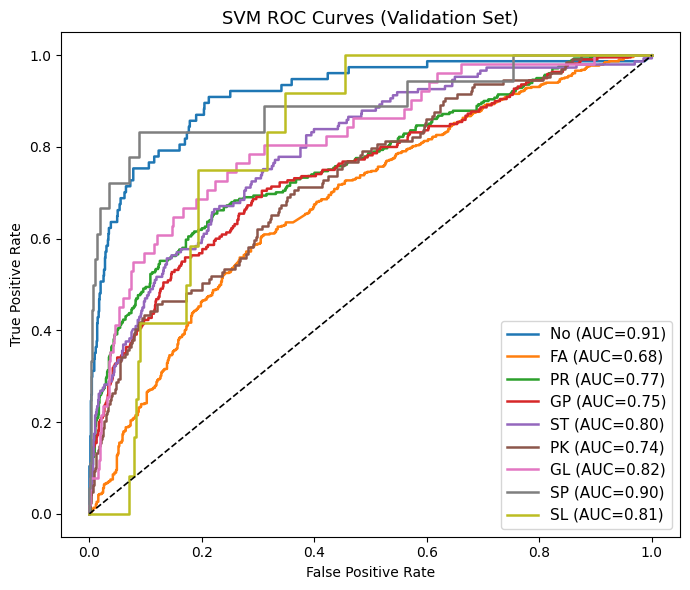

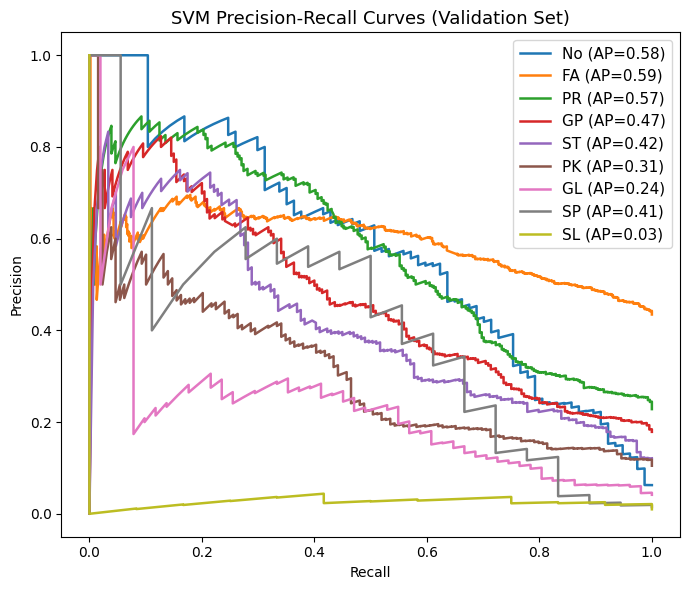

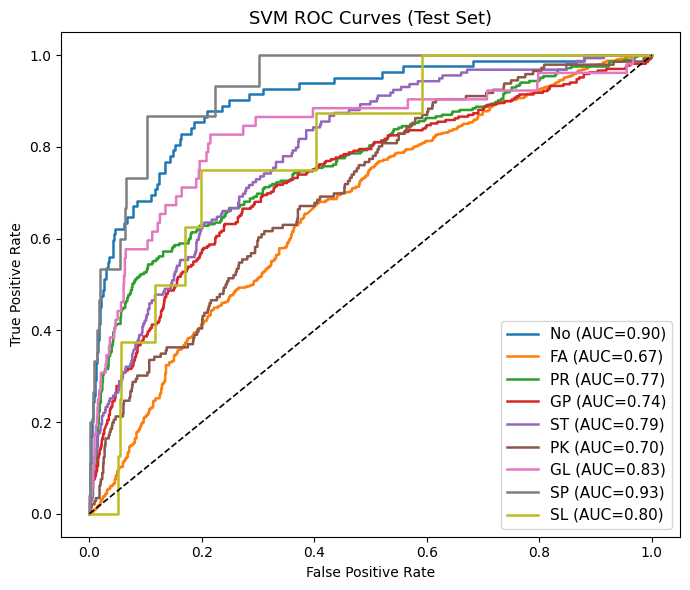

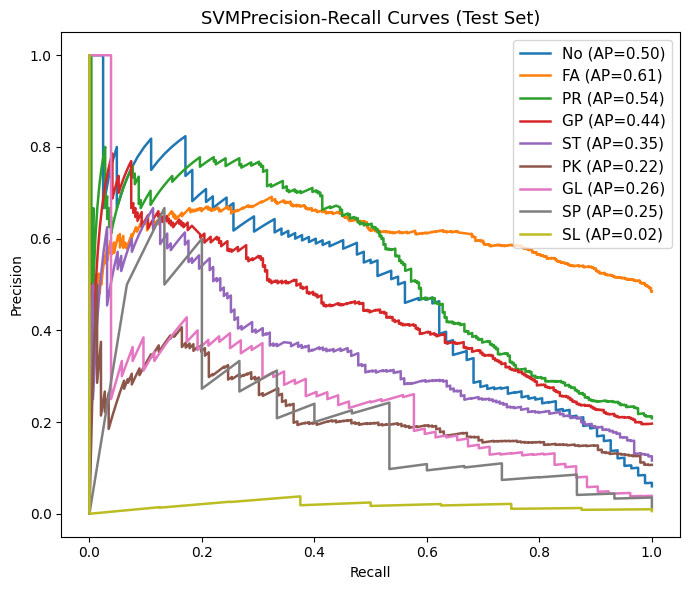

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.multioutput import ClassifierChain
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)

# -----------------------------
# 1. Load dataset
# -----------------------------
df = pd.read_csv("./data/train_dataset_with_features.csv")

# -----------------------------
# 2. Data preprocessing
# -----------------------------
# Parse the Sequence_features column: convert from string to numeric list
df["Sequence_features"] = df["Sequence_features"].apply(parse_feature_string)
df["Sequence_features"] = df["Sequence_features"].apply(
    lambda x: np.array(eval(x)) if isinstance(x, str) else np.array(x)
)

# -----------------------------
# 3. Construct feature and label matrices
# -----------------------------
X = np.stack(df["Sequence_features"].values)  # shape: (n_samples, n_features)

# Assume the Label column is already in string form "0 0 1 0 0 1 0 0 0"
df["Label"] = df["Label"].apply(lambda x: np.array([int(i) for i in str(x).split()]))

# Stack into a 2D array
Y = np.stack(df["Label"].values)  # shape: (n_samples, n_labels)

# -----------------------------
# 4. Split training and validation sets (9:1 ratio)
# -----------------------------
trainX, valX, trainY, valY = train_test_split(
    X, Y, test_size=0.1, random_state=42
)

print(f"Training feature matrix: {trainX.shape}, Validation feature matrix: {valX.shape}")
print(f"Training label matrix: {trainY.shape}, Validation label matrix: {valY.shape}")

# -----------------------------
# 5. Define model: Support Vector Machine + ClassifierChain
# -----------------------------
# -----------------------------
# Define base SVM model
# -----------------------------
svm_clf = SVC(kernel='linear', probability=True, random_state=0)

# -----------------------------
# Multi-label classifier
# -----------------------------
multi_target_svm = ClassifierChain(svm_clf)
print('Model training started....')

multi_target_svm.fit(trainX, trainY)

# -----------------------------
# 6. Model prediction
# -----------------------------
print('Model inference started....')

# -----------------------------
# 7. Compute evaluation metrics
# -----------------------------
def evaluate_metrics(y_true, y_pred, y_prob):
    metrics = {}
    metrics["Accuracy"]  = accuracy_score(y_true, y_pred)
    metrics["Precision"] = precision_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["Recall"]    = recall_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["F1-score"]  = f1_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["AUC-ROC"]   = roc_auc_score(y_true, y_prob, average="macro")
    metrics["AUC-PR"]    = average_precision_score(y_true, y_prob, average="macro")
    return metrics

# Training set predicted probabilities
trainY_prob = get_proba_matrix(multi_target_svm, trainX)
trainY_pred = (trainY_prob >= 0.5).astype(int)

train_metrics = evaluate_metrics(trainY, trainY_pred, trainY_prob)

# Validation set metrics
valY_prob = get_proba_matrix(multi_target_svm, valX)
valY_pred = (valY_prob >= 0.5).astype(int)
val_metrics = evaluate_metrics(valY, valY_pred, valY_prob)

# Load test set
df = pd.read_csv("./data/test_dataset_with_features.csv")

# -----------------------------
# 2. Data preprocessing
# -----------------------------
# Parse the Sequence_features column: convert from string to numeric list
df["Sequence_features"] = df["Sequence_features"].apply(parse_feature_string)
df["Sequence_features"] = df["Sequence_features"].apply(
    lambda x: np.array(eval(x)) if isinstance(x, str) else np.array(x)
)

# -----------------------------
# 3. Construct feature and label matrices
# -----------------------------
testX = np.stack(df["Sequence_features"].values)  # shape: (n_samples, n_features)

# Assume Label column is in string form "0 0 1 0 0 1 0 0 0"
df["Label"] = df["Label"].apply(lambda x: np.array([int(i) for i in str(x).split()]))

# Stack into 2D array
testY = np.stack(df["Label"].values)  # shape: (n_samples, n_labels)

# Test predicted probabilities
testY_prob = get_proba_matrix(multi_target_svm, testX)
testY_pred = (testY_prob >= 0.5).astype(int)
test_metrics = evaluate_metrics(testY, testY_pred, testY_prob)

# -----------------------------
# 8. Output results
# -----------------------------
print("\n📘 SVM Training Set Metrics:")
for k, v in train_metrics.items():
    print(f"{k:12s}: {v:.4f}")

print("\n📗 SVM Validation Set Metrics:")
for k, v in val_metrics.items():
    print(f"{k:12s}: {v:.4f}")

print("\n📗 SVM Test Set Metrics:")
for k, v in test_metrics.items():
    print(f"{k:12s}: {v:.4f}")

# If your 9 label names are known
label_names = ["No","FA","PR","GP","ST","PK","GL","SP","SL"]

# -----------------------------
# 6. Plot ROC curves for validation set
# -----------------------------
plt.figure(figsize=(7,6))
for i in range(Y.shape[1]):
    fpr, tpr, _ = roc_curve(valY[:, i], valY_prob[:, i])
    auc = roc_auc_score(valY[:, i], valY_prob[:, i])
    plt.plot(fpr, tpr, lw=1.8, label=f"{label_names[i]} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=1.2)
plt.xlabel("False Positive Rate", fontsize=10)
plt.ylabel("True Positive Rate", fontsize=10)
plt.title("SVM ROC Curves (Validation Set)", fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("SVM_val_roc_curves.png", dpi=300)
plt.show()

# -----------------------------
# 7. Plot Precision-Recall curves for validation set
# -----------------------------
plt.figure(figsize=(7,6))
for i in range(Y.shape[1]):
    precision, recall, _ = precision_recall_curve(valY[:, i], valY_prob[:, i])
    ap = average_precision_score(valY[:, i], valY_prob[:, i])
    plt.plot(recall, precision, lw=1.8, label=f"{label_names[i]} (AP={ap:.2f})")

plt.xlabel("Recall", fontsize=10)
plt.ylabel("Precision", fontsize=10)
plt.title("SVM Precision-Recall Curves (Validation Set)", fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("SVM_val_pr_curves.png", dpi=300)
plt.show()

# -----------------------------
# 8. Plot ROC curves for test set
# -----------------------------
plt.figure(figsize=(7,6))
for i in range(Y.shape[1]):
    fpr, tpr, _ = roc_curve(testY[:, i], testY_prob[:, i])
    auc = roc_auc_score(testY[:, i], testY_prob[:, i])
    plt.plot(fpr, tpr, lw=1.8, label=f"{label_names[i]} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=1.2)
plt.xlabel("False Positive Rate", fontsize=10)
plt.ylabel("True Positive Rate", fontsize=10)
plt.title("SVM ROC Curves (Test Set)", fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("SVM_test_roc_curves.png", dpi=300)
plt.show()

# -----------------------------
# 9. Plot Precision-Recall curves for test set
# -----------------------------
plt.figure(figsize=(7,6))
for i in range(Y.shape[1]):
    precision, recall, _ = precision_recall_curve(testY[:, i], testY_prob[:, i])
    ap = aver
